In [ ]:
!pip install info-nce-pytorch

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../../')

import phys_ml.visualization.vertex_visualization as vertvis
import phys_ml.visualization.base as vis
from phys_ml.analysis.vertex import *
from phys_ml.evaluation import vertex as verteval
from phys_ml.load_data.vertex import *
from phys_ml.trainer.vertex import *
from phys_ml.util import slurm_generate

In [30]:
run_ids = ['1_1', '1_2', '2_1_1', '2_1_2', '2_2_1', '2_2_2', '2_3_1', '2_3_2', '3_1', '3_2', '3_3']
latent_dims = [8, 16, 20, 24, 32]
ssizes = [2000, 8000, 12000, 16000]

## contents

&emsp;0&emsp;on real space  
&emsp;1&emsp;trained on all vertices  
&emsp;&emsp;1-1&emsp;simple autoencoder  
&emsp;&emsp;1-2&emsp;contrastive autoencoder  
&emsp;2&emsp;trained on only 2 phases  
&emsp;&emsp;2-1&emsp;exclude SC-phase  
&emsp;&emsp;&emsp;2-1-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-1-2&emsp;contrastive autoencoder  
&emsp;&emsp;2-2&emsp;exclude AFM-phase  
&emsp;&emsp;&emsp;2-2-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-2-2&emsp;contrastive autoencoder  
&emsp;&emsp;2-3&emsp;exclude FM-phase  
&emsp;&emsp;&emsp;2-3-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-3-2&emsp;contrastive autoencoder  
&emsp;3&emsp;trained on only 1 phase  
&emsp;&emsp;3-1&emsp;SC-phase  
&emsp;&emsp;3-2&emsp;AFM-phase  
&emsp;&emsp;3-3&emsp;FM-phase  
&emsp;4&emsp;correlation  
&emsp;5&emsp;convergence  

## slurm

In [31]:
for run_id in run_ids:
    for ld in latent_dims:
        print(f'sbatch vertex_{run_id}_ld{ld}.slrm')
    for s in ssizes:
        print(f'sbatch vertex_{run_id}_s{s}.slrm')

sbatch vertex_1_1_ld8.slrm
sbatch vertex_1_1_ld16.slrm
sbatch vertex_1_1_ld20.slrm
sbatch vertex_1_1_ld24.slrm
sbatch vertex_1_1_ld32.slrm
sbatch vertex_1_1_s2000.slrm
sbatch vertex_1_1_s8000.slrm
sbatch vertex_1_1_s12000.slrm
sbatch vertex_1_1_s16000.slrm
sbatch vertex_1_2_ld8.slrm
sbatch vertex_1_2_ld16.slrm
sbatch vertex_1_2_ld20.slrm
sbatch vertex_1_2_ld24.slrm
sbatch vertex_1_2_ld32.slrm
sbatch vertex_1_2_s2000.slrm
sbatch vertex_1_2_s8000.slrm
sbatch vertex_1_2_s12000.slrm
sbatch vertex_1_2_s16000.slrm
sbatch vertex_2_1_1_ld8.slrm
sbatch vertex_2_1_1_ld16.slrm
sbatch vertex_2_1_1_ld20.slrm
sbatch vertex_2_1_1_ld24.slrm
sbatch vertex_2_1_1_ld32.slrm
sbatch vertex_2_1_1_s2000.slrm
sbatch vertex_2_1_1_s8000.slrm
sbatch vertex_2_1_1_s12000.slrm
sbatch vertex_2_1_1_s16000.slrm
sbatch vertex_2_1_2_ld8.slrm
sbatch vertex_2_1_2_ld16.slrm
sbatch vertex_2_1_2_ld20.slrm
sbatch vertex_2_1_2_ld24.slrm
sbatch vertex_2_1_2_ld32.slrm
sbatch vertex_2_1_2_s2000.slrm
sbatch vertex_2_1_2_s8000.slrm


In [ ]:
# watch jobs
squeue -u shepp123

In [46]:
# config
base_dir = '/gpfs/data/fs71925/shepp123/'

def create_slurm(version: str, contrastive: bool = False, hidden_dims: list[int] = [128, 64, 32], epochs: int = -1,
                 sample_count_per_vertex: int = -1, subset: float|int|None = None, subset_type: list[str]|str|None = None,
                 batch_size: int = -1, qos: str = 'zen3_0512_a100x2', time: str = '24:00:00'):
    model_wrapper = 'VertexWrapper24x6InfoNCE' if contrastive else 'VertexWrapper24x6'
    model_name = 'ContrastiveAutoEncoder' if contrastive else 'AutoEncoderVertex'
    dataset = 'AutoEncoder24x6InfoNCEDataset' if contrastive else 'AutoEncoderVertex24x6Dataset'
    if epochs == -1:
        epochs = 50_000 if contrastive else 25_000
    if sample_count_per_vertex == -1:
        sample_count_per_vertex = 24_000
    if batch_size == -1:
        batch_size = 2048 if contrastive else 8192
    if contrastive:
        sample_count_per_vertex = sample_count_per_vertex // 4
    trainer_kwargs = {
        'config_name': 'confmod_auto_encoder.json', 
        'subconfig_name': 'AUTO_ENCODER_VERTEX_24X6', 
        'config_kwargs': {
            'path_train': base_dir + 'frgs_6d',
            'resume': 'run_results/' + version,
            'model_wrapper': model_wrapper,
            'model_name': model_name,
            'dataset': dataset,
            'hidden_dims': hidden_dims,
            'epochs': epochs,
            'sample_count_per_vertex': sample_count_per_vertex, 
            'test_ratio': 0.2, 
            'subset': subset, 
            'subset_type': subset_type,
            'subset_shuffle': False, 
            'devices': 'auto', 
            'device_type': 'gpu', 
            'num_dataloader_workers': 2, 
            'batch_size': batch_size,
            'callbacks_kwargs': {
                'EarlyStopping': {'monitor': 'val_loss', 'mode': 'min', 'patience': 100, 'verbose': True}
            },
        },
    }
    slurm_options = slurm_generate.SlurmOptions(qos=qos, time=time, mail_user='e1015083@student.tuwien.ac.at')
    slurm_kwargs = {'project_name': 'vertex_24x6', 'pyenv_dir': base_dir + 'PhysML/.venv', 
                    'trainer': 'vertex.VertexTrainer24x6', 'slurm_options': slurm_options, 'trainer_kwargs': trainer_kwargs}
    slurm_generate.create(script_name='vertex_' + version, **slurm_kwargs)


def create_all_scripts():
    run_configs = {
        '1_1': {}, 
        '1_2': {'contrastive': True}, 
        '2_1_1': {'subset': 0.8, 'subset_type': ['afm', 'fm']}, 
        '2_1_2': {'contrastive': True, 'subset': 0.8, 'subset_type': ['afm', 'fm']},
        '2_2_1': {'subset': 0.8, 'subset_type': ['sc', 'fm']},
        '2_2_2': {'contrastive': True, 'subset': 0.8, 'subset_type': ['sc', 'fm']},
        '2_3_1': {'subset': 0.8, 'subset_type': ['afm', 'sc']},
        '2_3_2': {'contrastive': True, 'subset': 0.8, 'subset_type': ['afm', 'sc']},
        '3_1': {'subset': 0.8, 'subset_type': 'sc'},
        '3_2': {'subset': 0.8, 'subset_type': 'afm'},
        '3_3': {'subset': 0.8, 'subset_type': 'fm'},
    }
    ld_configs = [
        {'hidden_dims': [128, 64, 32, 8]},
        {'hidden_dims': [128, 64, 32, 16]},
        {'hidden_dims': [128, 64, 32, 20]},
        {'hidden_dims': [128, 64, 24]},
        {'hidden_dims': [128, 64, 32]},
    ]
    s_configs = [
        {'sample_count_per_vertex': 2000},
        {'sample_count_per_vertex': 8000},
        {'sample_count_per_vertex': 12000},
        {'sample_count_per_vertex': 16000},
    ]

    for run_id, run_args in run_configs.items():
        for ld_config in ld_configs:
            ld = ld_config['hidden_dims'][-1]
            create_slurm(version=f'{run_id}_ld{ld}', **run_args, **ld_config)
        for s_config in s_configs:
            s = s_config['sample_count_per_vertex']
            create_slurm(version=f'{run_id}_s{s}', **run_args, **s_config)

create_all_scripts()

## setup

In [ ]:
from sklearn import ensemble, svm


# load vertices
path_train = '../../../frgs_6d'
file_paths = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=None, subset_shuffle=False)[0]
vertices = AutoEncoderVertex24x6Dataset.load_vertex_files(file_paths)

# autoencoder
seed = 42
hidden_dims = [128, 64, 32]
train_samples_per_vertex = 24000
nce_train_samples = train_samples_per_vertex // 4
test_samples_per_vertex = 2000
# config_kwargs = {
#     'hidden_dims': hidden_dims,
#     'epochs': 1000,
#     'test_ratio': 0.2, 
#     'devices': 'auto', 
#     'num_dataloader_workers': 16, 
#     'strategy': 'auto', 
#     'batch_size': 8192 * 2,
# }
dataset_kwargs = {
    'path_train': path_train, 
    'subset_shuffle': False, 
}

# phase classifier
pc_models = [
    # svm.SVC(verbose=True, random_state=seed + 1), 
    ensemble.RandomForestClassifier(n_jobs=-1, verbose=0, random_state=seed + 2),
]

In [ ]:
# general train sets
# train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex, dataset_kwargs)
nce_train_dataset = verteval.make_dataset(vertices, nce_train_samples, dataset_kwargs, dataset_class=AutoEncoder24x6InfoNCEDataset)
nce_train_dataset_subset = verteval.make_dataset(vertices, nce_train_samples, dataset_kwargs, subset=0.8, 
                                                 dataset_class=AutoEncoder24x6InfoNCEDataset)

# reconstruction filepaths
ex_sc_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                       subset_seed=seed, subset_type=['afm', 'fm'], file_paths=file_paths)[0]
ex_sc_fps = list(set(file_paths) - set(ex_sc_fps))
ex_afm_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                        subset_seed=seed, subset_type=['sc', 'fm'], file_paths=file_paths)[0]
ex_afm_fps = list(set(file_paths) - set(ex_afm_fps))
ex_fm_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                       subset_seed=seed, subset_type=['afm', 'sc'], file_paths=file_paths)[0]
ex_fm_fps = list(set(file_paths) - set(ex_fm_fps))
sc_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                    subset_seed=seed, subset_type='sc', file_paths=file_paths)[0]
sc_fps = list(set(file_paths) - set(sc_fps))
afm_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                     subset_seed=seed, subset_type='afm', file_paths=file_paths)[0]
afm_fps = list(set(file_paths) - set(afm_fps))
fm_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                    subset_seed=seed, subset_type='fm', file_paths=file_paths)[0]
fm_fps = list(set(file_paths) - set(fm_fps))

# test sets
test_dataset_full = verteval.make_dataset(vertices, test_samples_per_vertex, dataset_kwargs, dataset_class=AutoEncoder24x6InfoNCEDataset)
test_dataset_subset = verteval.make_test_from_train_dataset(vertices, path_train, dataset_kwargs, test_samples_per_vertex, nce_train_dataset_subset)


# evaluate models

In [ ]:
import pandas as pd
from tqdm.notebook import tqdm

base_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/'

run_info = {
    '1_1': (file_paths, nce_train_dataset, test_dataset_full), 
    '1_2': (file_paths, nce_train_dataset, test_dataset_full), 
    '2_1_1': (ex_sc_fps, nce_train_dataset_subset, test_dataset_subset), 
    '2_1_2': (ex_sc_fps, nce_train_dataset_subset, test_dataset_subset), 
    '2_2_1': (ex_afm_fps, nce_train_dataset_subset, test_dataset_subset), 
    '2_2_2': (ex_afm_fps, nce_train_dataset_subset, test_dataset_subset), 
    '2_3_1': (ex_fm_fps, nce_train_dataset_subset, test_dataset_subset), 
    '2_3_2': (ex_fm_fps, nce_train_dataset_subset, test_dataset_subset), 
    '3_1': (sc_fps, nce_train_dataset_subset, test_dataset_subset), 
    '3_2': (afm_fps, nce_train_dataset_subset, test_dataset_subset), 
    '3_3': (fm_fps, nce_train_dataset_subset, test_dataset_subset),
}

save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/'
rmse_df = pd.DataFrame(columns=['run_id', 'ld', 's', 'tp', 'rmse', 'train_data'])
classification_df = pd.DataFrame(columns=['run_id', 'ld', 's', 'f1', 'conf_mat'])
try:
    rmse_df = pd.read_csv(save_path + 'reconstruction_results.csv')
    classification_df = pd.read_pickle(save_path + 'classification_results.pkl')
except:
    pass


def eval(prog: tqdm, run_id: str, run_name: str, ld: int, s: int):
    prog.set_description(f'Evaluating {run_name}')
    model_path = base_path + run_name

    if os.path.exists(model_path):
        # reconstruction
        if len(rmse_df[(rmse_df['run_id'] == run_id) 
                    & (rmse_df['ld'] == ld) 
                    & (rmse_df['s'] == s)]) < len(file_paths):
            rmses = verteval.mean_rmse(file_paths, vertices, model_path)
            is_train_data = [fp not in recon_files for fp in file_paths]
            for is_td, (tp, rmse) in zip(is_train_data, rmses.items()):
                rmse_df.loc[len(rmse_df)] = [run_id, ld, s, tp, rmse, is_td]
            rmse_df.to_csv(save_path + 'reconstruction_results.csv', index=False)

        # classification
        if classification_df[(classification_df['run_id'] == run_id)
                            & (classification_df['ld'] == ld) 
                            & (classification_df['s'] == s)].empty:
            pc = PhaseClassification(model_path, pc_models, run_name)
            pc.train(nce_train_dataset)
            model_scores = pc.evaluate_classifiers(test_dataset_full, print_conf_mat=False)
            pc_results = list(model_scores.values())[0]
            classification_df.loc[len(classification_df)] = [run_id, ld, s, pc_results[0]['f1'], pc_results[1]]
            classification_df.to_pickle(save_path + 'classification_results.pkl')
    prog.update()


total = len(run_info) * (len(latent_dims) + len(ssizes))
with tqdm(total=total, desc='Evaluation') as prog:
    for run_id, (recon_files, train_data, test_data) in run_info.items():
        for ld in latent_dims:
            run_name = f'{run_id}_ld{ld}'
            eval(prog, run_id, run_name, ld, 24_000)
        for s in ssizes:
            run_name = f'{run_id}_s{s}'
            eval(prog, run_id, run_name, 32, s)

# show results

In [7]:
rmse_df = pd.read_csv('reconstruction_results.csv')
classification_df = pd.read_pickle('classification_results.pkl')

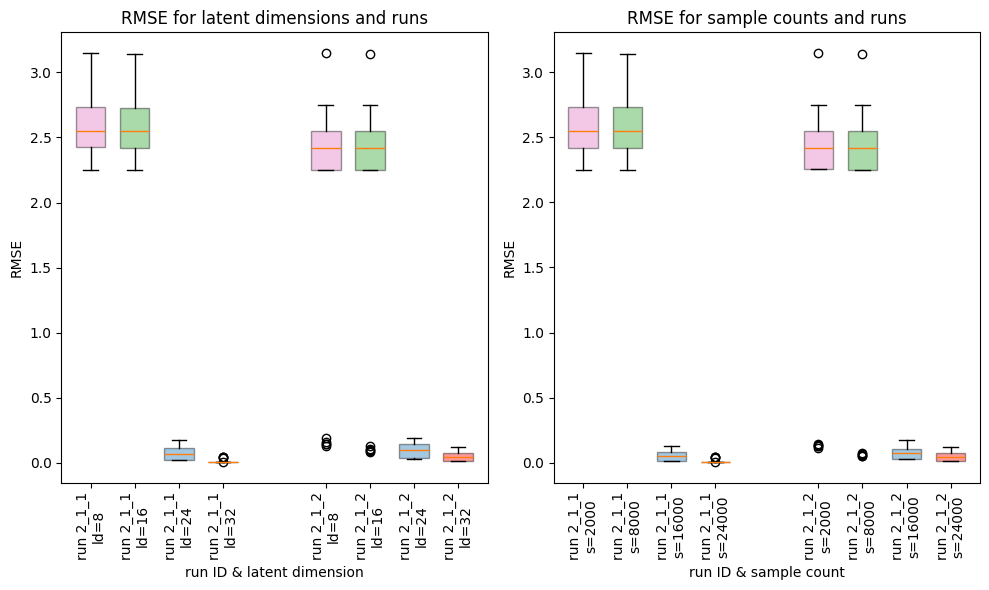

rmse
run_id ld s              
2_1_1  8  24000  2.683142
       16 24000  2.675942
       24 24000  0.080148
       32 2000   2.676035
          8000   2.674256
          16000  0.055903
          24000  0.013185
2_1_2  8  24000  2.069679
       16 24000  2.055018
       24 24000  0.098643
       32 2000   2.063470
          8000   2.042674
          16000  0.082347
          24000  0.050142

In [38]:
verteval.plot_all_rmses(rmse_df, train_data=False, figsize=(10, 6))

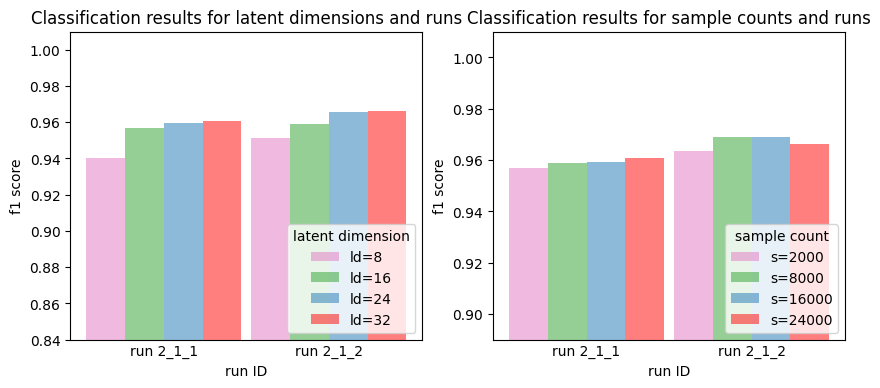

f1
run_id ld s              
2_1_1  8  24000  0.940110
       16 24000  0.957021
       24 24000  0.959446
       32 2000   0.956765
          8000   0.958727
          16000  0.959113
          24000  0.960729
2_1_2  8  24000  0.951040
       16 24000  0.959179
       24 24000  0.965585
       32 2000   0.963471
          8000   0.968983
          16000  0.968869
          24000  0.966148

In [40]:
verteval.plot_classification_results(classification_df, figsize=(10, 4))

# convergence

In [61]:
from pathlib import Path

base_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/'
folders = sorted([f.name for f in Path(base_path).iterdir() if f.is_dir()])
labels = {
    '1_1': '1-1 all vertices, simple AE',
    '1_2': '1-2 all vertices, contrastive AE',
    '2_1_1': '2-1-1 exclude SC, simple AE',
    '2_1_2': '2-1-2 exclude SC, contrastive AE',
    '2_2_1': '2-2-1 exclude AFM, simple AE',
    '2_2_2': '2-2-2 exclude AFM, contrastive AE',
    '2_3_1': '2-3-1 exclude FM, simple AE',
    '2_3_2': '2-3-2 exclude FM, contrastive AE',
    '3_1': '3-1 SC only, simple AE',
    '3_2': '3-2 AFM only, simple AE',
    '3_3': '3-3 FM only, simple AE',
}

filtered_folders = folders  # set this to plot only some runs
filtered_labels = []
for f in filtered_folders:
    fsplit = f.split('_')
    pref, suff = '_'.join(fsplit[:-1]), fsplit[-1]
    filtered_labels.append(f"{labels[pref]} ({suff})")
tensorboard_data = vis.get_tensorboard_data(base_path, filtered_folders, filtered_labels)
tensorboard_stats = vis.get_tensorboard_statistics(tensorboard_data)
tensorboard_stats

,wall_time,epoch
run,,
"1-1 all vertices, simple AE (ld32)",35.96,21895
"1-2 all vertices, contrastive AE (ld32)",14.95,24999
"2-1-1 exclude SC, simple AE (ld16)",2.12,2162
"2-1-1 exclude SC, simple AE (ld24)",2.38,2408
"2-1-1 exclude SC, simple AE (ld32)",24.26,24999
"2-1-1 exclude SC, simple AE (ld8)",2.94,2993
"2-1-1 exclude SC, simple AE (s16000)",3.02,4677
"2-1-1 exclude SC, simple AE (s2000)",0.47,4905
"2-1-1 exclude SC, simple AE (s8000)",1.33,3974


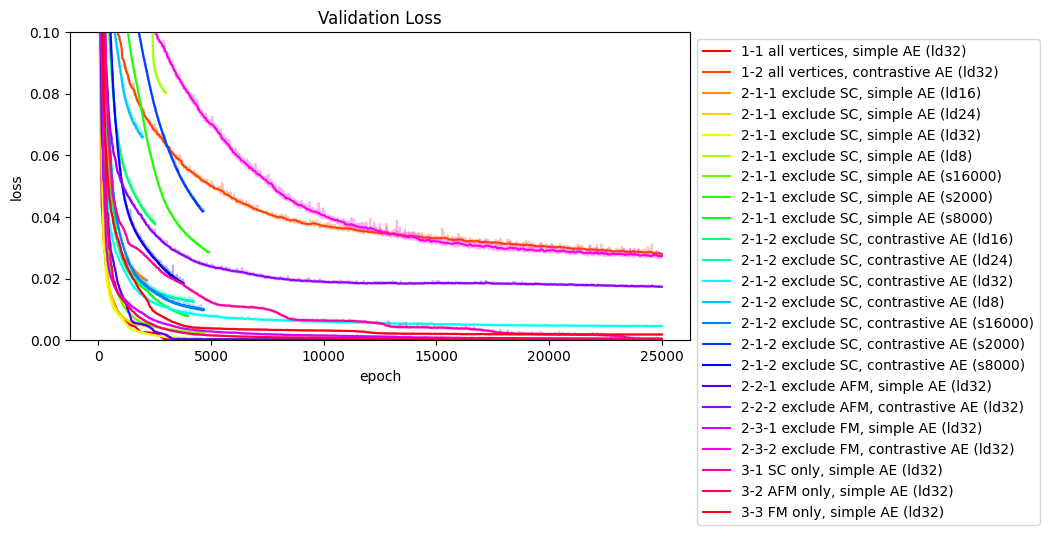

In [42]:
vis.plot_loss_progress(tensorboard_data.dropna(), labels, y_max=0.1, log=False)